# Benchmark des Modéles de Segmentation (U-Net vs DeepLabV3+ vs MedSAM)

Ce notebook permet de charger les 3 modèles entraînés sur le dataset ISIC 2018 et de comparer visuellement et quantitativement leurs performances de segmentation sur une sélection d'images de test.

Les modèles comparés sont :
1. **U-Net** (Entraîné à partir de zéro, architecture standard)
2. **DeepLabV3+** (Avec backbone ResNet50 pré-entraîné et module ASPP)
3. **MedSAM** (Modèle pré-entraîné de pointe basé sur Vision Transformers, guidé par Bounding Box)

In [1]:
# Connexion à Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Se placer dans le dossier du projet P9
import os
os.chdir('/content/drive/MyDrive/P9/Src')

Mounted at /content/drive


In [2]:
# 1. Installation de la librairie originale de Meta (Facebook) : Segment Anything
!pip install git+https://github.com/facebookresearch/segment-anything.git
!pip install opencv-python matplotlib numpy torch torchvision

from segment_anything import sam_model_registry, SamPredictor

  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-lf1a5k37
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-lf1a5k37
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
  Created wheel for segment_anything: filename=segment_anything-1.0-py3-none-any.whl size=36592 sha256=b914fb19225f76410f70c52db2cb2484a8b018ed41365e892adae94450768bba
  Stored in directory: /tmp/pip-ephem-wheel-cache-cgsw059y/wheels/29/82/ff/04e2be9805a1cb48bec0b85b5a6da6b63f647645750a0e42d4
Successfully built segment_anything


In [5]:
# ==========================================
# 1. IMPORTS DE LA BIBLIOTHÈQUE STANDARD & TIERS
# ==========================================
import os
import glob
import random
import cv2
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 2. DEEP LEARNING (TENSORFLOW & PYTORCH)
# ==========================================
import tensorflow as tf
# Configuration du GPU pour TensorFlow : on force TensorFlow sur CPU pour libérer toute la VRAM GPU pour PyTorch (MedSAM)
tf.config.set_visible_devices([], 'GPU')
print("✅ GPU masqué pour TensorFlow (exécution forcée sur CPU pour économiser la VRAM)")
from tensorflow.keras import backend as K
from tensorflow.keras.models import load_model

import torch
from segment_anything import sam_model_registry, SamPredictor

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print(f"✅ Appareil PyTorch : {device}")

✅ Memory Growth activée sur 1 GPU(s)
✅ Appareil PyTorch : cuda


# Chargement des données

In [6]:
isic_dir_drive = "/content/drive/MyDrive/P9/Src/Data/ISIC2018"
local_base_dir = "/content/P9/Data/ISIC2018"

zip_files = glob.glob(os.path.join(isic_dir_drive, "**/*.zip"), recursive=True)

if not zip_files:
    print(f"❌ Aucun fichier ZIP trouvé dans {isic_dir_drive}")
else:
    print(f"📦 {len(zip_files)} fichiers ZIP trouvés. Décompression...")
    for zip_path in zip_files:
        sub_folder = os.path.relpath(os.path.dirname(zip_path), isic_dir_drive)
        local_extract_dir = os.path.join(local_base_dir, sub_folder)
        os.makedirs(local_extract_dir, exist_ok=True)
        print(f"Extraction de {os.path.basename(zip_path)} dans {local_extract_dir}...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(local_extract_dir)
    print(f"✅ Extraction terminée dans {local_base_dir}")

📦 6 fichiers ZIP trouvés. Décompression...
Extraction de Test_GroundTruth.zip dans /content/P9/Data/ISIC2018/test...
Extraction de Test_Input.zip dans /content/P9/Data/ISIC2018/test...
Extraction de Training_GroundTruth.zip dans /content/P9/Data/ISIC2018/train...
Extraction de Training_Input.zip dans /content/P9/Data/ISIC2018/train...
Extraction de Validation_GroundTruth.zip dans /content/P9/Data/ISIC2018/validation...
Extraction de Validation_Input.zip dans /content/P9/Data/ISIC2018/validation...
✅ Extraction terminée dans /content/P9/Data/ISIC2018


In [7]:
# ==========================================
# 1. DÉFINITION DES MÉTRIQUES ET LOSSES POUR KERAS
# ==========================================
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def iou(y_true, y_pred, smooth=1e-6):
    intersection = K.sum(K.abs(y_true * y_pred), axis=[1,2,3])
    union = K.sum(y_true,[1,2,3]) + K.sum(y_pred,[1,2,3]) - intersection
    iou = K.mean((intersection + smooth) / (union + smooth), axis=0)
    return iou

# ==========================================
# 2. FONCTIONS DE CALCUL DU DICE POUR EVALUATION NUMPY
# ==========================================
def compute_dice_numpy(mask_gt, mask_pred):
    intersection = np.sum(mask_gt * mask_pred)
    sum_gt = np.sum(mask_gt)
    sum_pred = np.sum(mask_pred)
    if sum_gt + sum_pred == 0:
        return 1.0
    return (2.0 * intersection) / (sum_gt + sum_pred)

def compute_iou_numpy(mask_gt, mask_pred):
    intersection = np.sum(mask_gt * mask_pred)
    union = np.sum(mask_gt) + np.sum(mask_pred) - intersection
    if union == 0:
        return 1.0
    return intersection / union

# ==========================================
# 3. EXTRACTION DE LA BOUNDING BOX POUR MedSAM
# ==========================================
def get_bounding_box(mask, margin=20):
    y_indices, x_indices = np.where(mask > 0)
    if len(y_indices) == 0 or len(x_indices) == 0:
        return [0, 0, 0, 0]

    x_min, x_max = np.min(x_indices), np.max(x_indices)
    y_min, y_max = np.min(y_indices), np.max(y_indices)

    H, W = mask.shape
    x_min = max(0, x_min - margin)
    y_min = max(0, y_min - margin)
    x_max = min(W, x_max + margin)
    y_max = min(H, y_max + margin)

    return [x_min, y_min, x_max, y_max]

In [ ]:
# ==========================================
# CHARGEMENT DES 3 MODÈLES
# ==========================================
custom_objects = {
    'dice_coef': dice_coef,
    'dice_loss': dice_loss,
    'iou': iou
}

# 1. Chargement de U-Net
unet_path = '/content/drive/MyDrive/P9/Src/models/best_unet_isic2018.h5'
print(f"Chargement de U-Net depuis {unet_path}...")
unet_model = load_model(unet_path, custom_objects=custom_objects)
print("✅ U-Net chargé avec succès !")

# 2. Chargement de DeepLabV3+
deeplab_path = '/content/drive/MyDrive/P9/Src/models/best_deeplabv3+_isic2018.h5'
print(f"Chargement de DeepLabV3+ depuis {deeplab_path}...")
deeplab_model = load_model(deeplab_path, custom_objects=custom_objects)
print("✅ DeepLabV3+ chargé avec succès !")

# 3. Chargement de MedSAM
medsam_checkpoint = '/content/drive/MyDrive/P9/Src/models/medsam_vit_b.pth'
if not os.path.exists(medsam_checkpoint):
    # Fallback si le modèle est dans le dossier local
    medsam_checkpoint = 'models/medsam_vit_b.pth'

print(f"Chargement de MedSAM depuis {medsam_checkpoint}...")
medsam_model = sam_model_registry["vit_b"](checkpoint=None)
state_dict = torch.load(medsam_checkpoint, map_location=device)
medsam_model.load_state_dict(state_dict)
medsam_model = medsam_model.to(device)
medsam_model.eval()

# Initialisation du Predictor MedSAM
predictor = SamPredictor(medsam_model)
print("✅ MedSAM chargé avec succès !")

In [ ]:
# Chemins des données de Test sur le SSD local de Colab
test_images_dir = '/content/P9/Data/ISIC2018/test/Test_Input'
test_masks_dir = '/content/P9/Data/ISIC2018/test/Test_GroundTruth'

# Lister et trier les fichiers
test_images_paths = sorted(glob.glob(os.path.join(test_images_dir, '*.jpg')))
test_masks_paths = sorted(glob.glob(os.path.join(test_masks_dir, '*.png')))

print(f"Nombre total d'images de test : {len(test_images_paths)}")

# Sélection de quelques images représentatives
random.seed(42)
selected_indices = random.sample(range(len(test_images_paths)), 4)
print(f"Indices sélectionnés pour le benchmark : {selected_indices}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 640ms/step


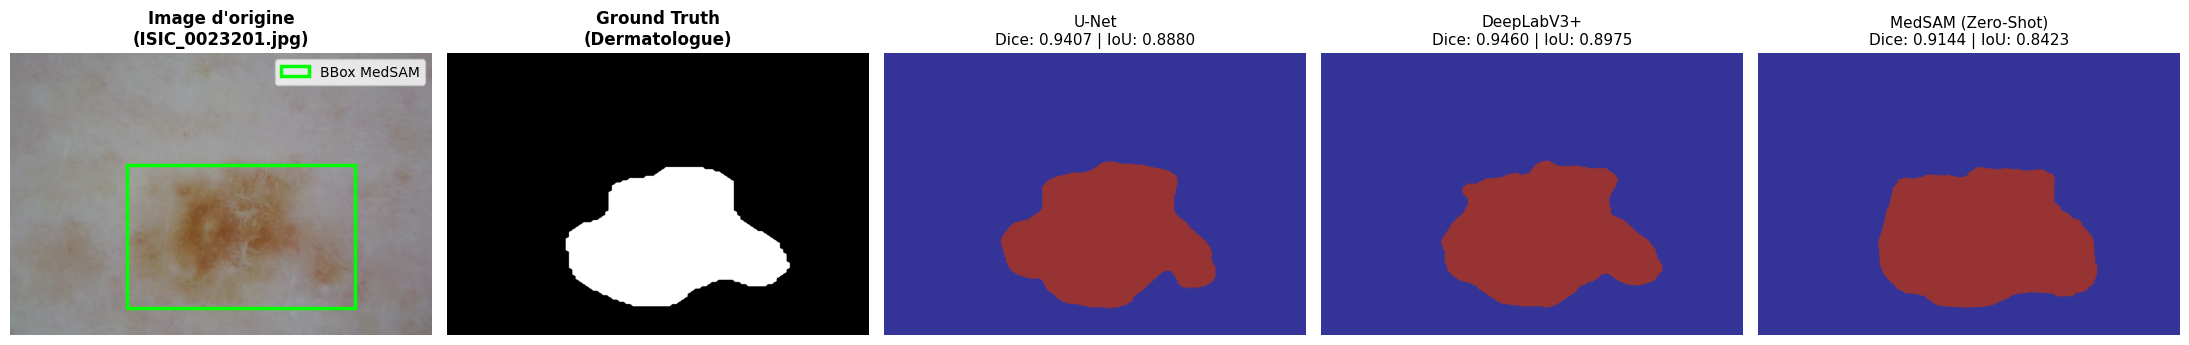

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 649ms/step


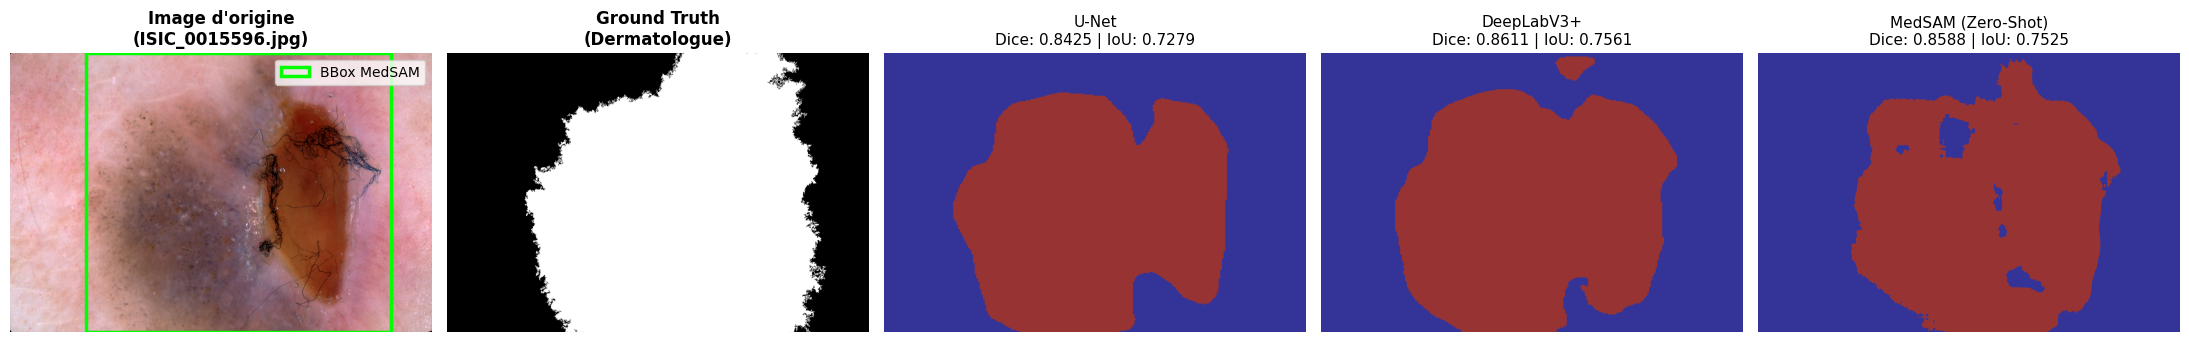

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 602ms/step


/tmp/ipykernel_5887/2285173415.py:127: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


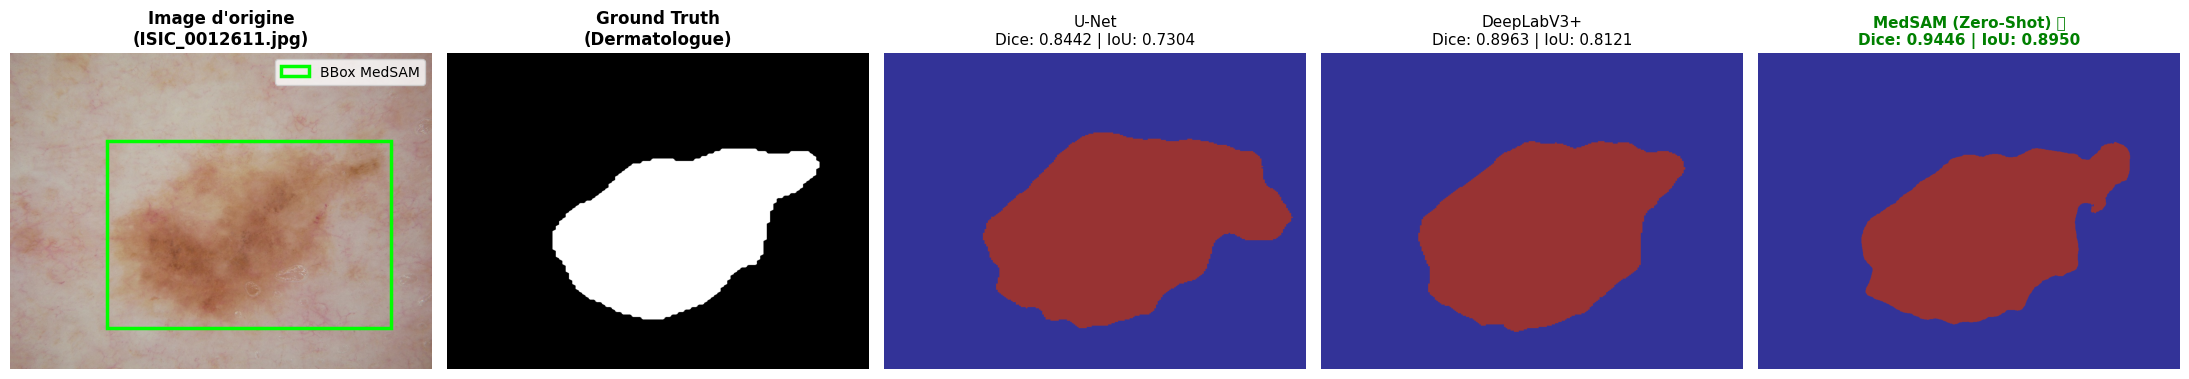

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 671ms/step


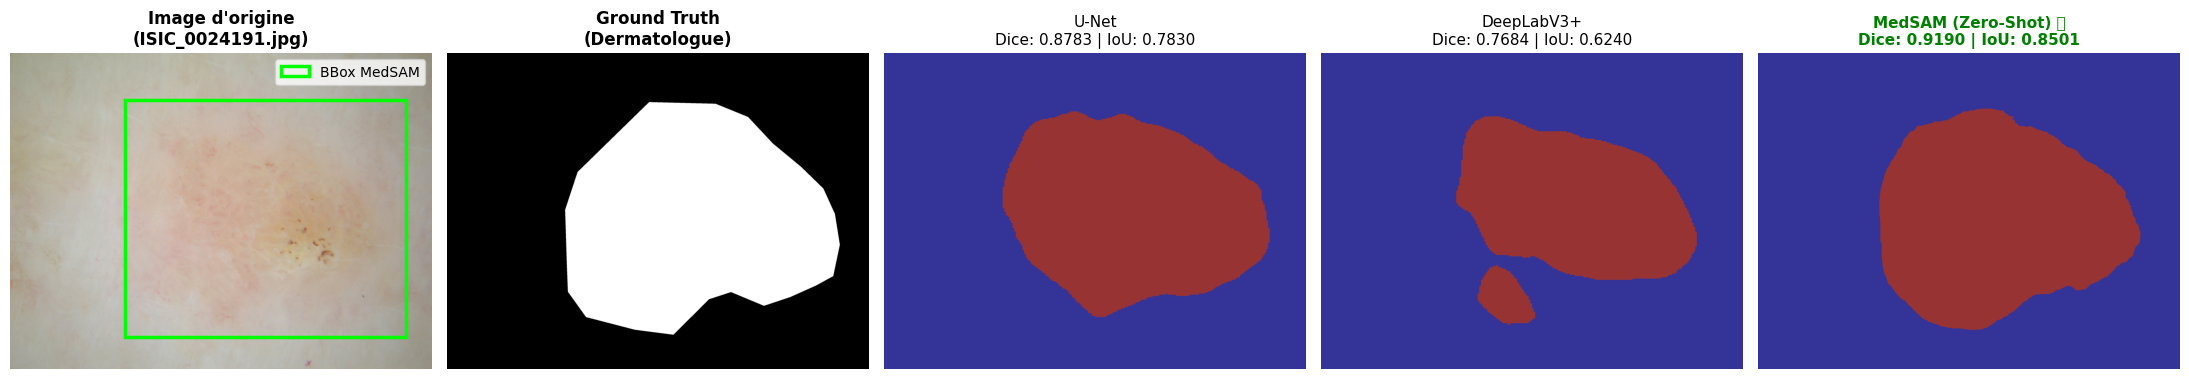


             TESTS CONCATÉNÉS OÙ MedSAM A GAGNÉ (🏆)


/tmp/ipykernel_5887/2285173415.py:182: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


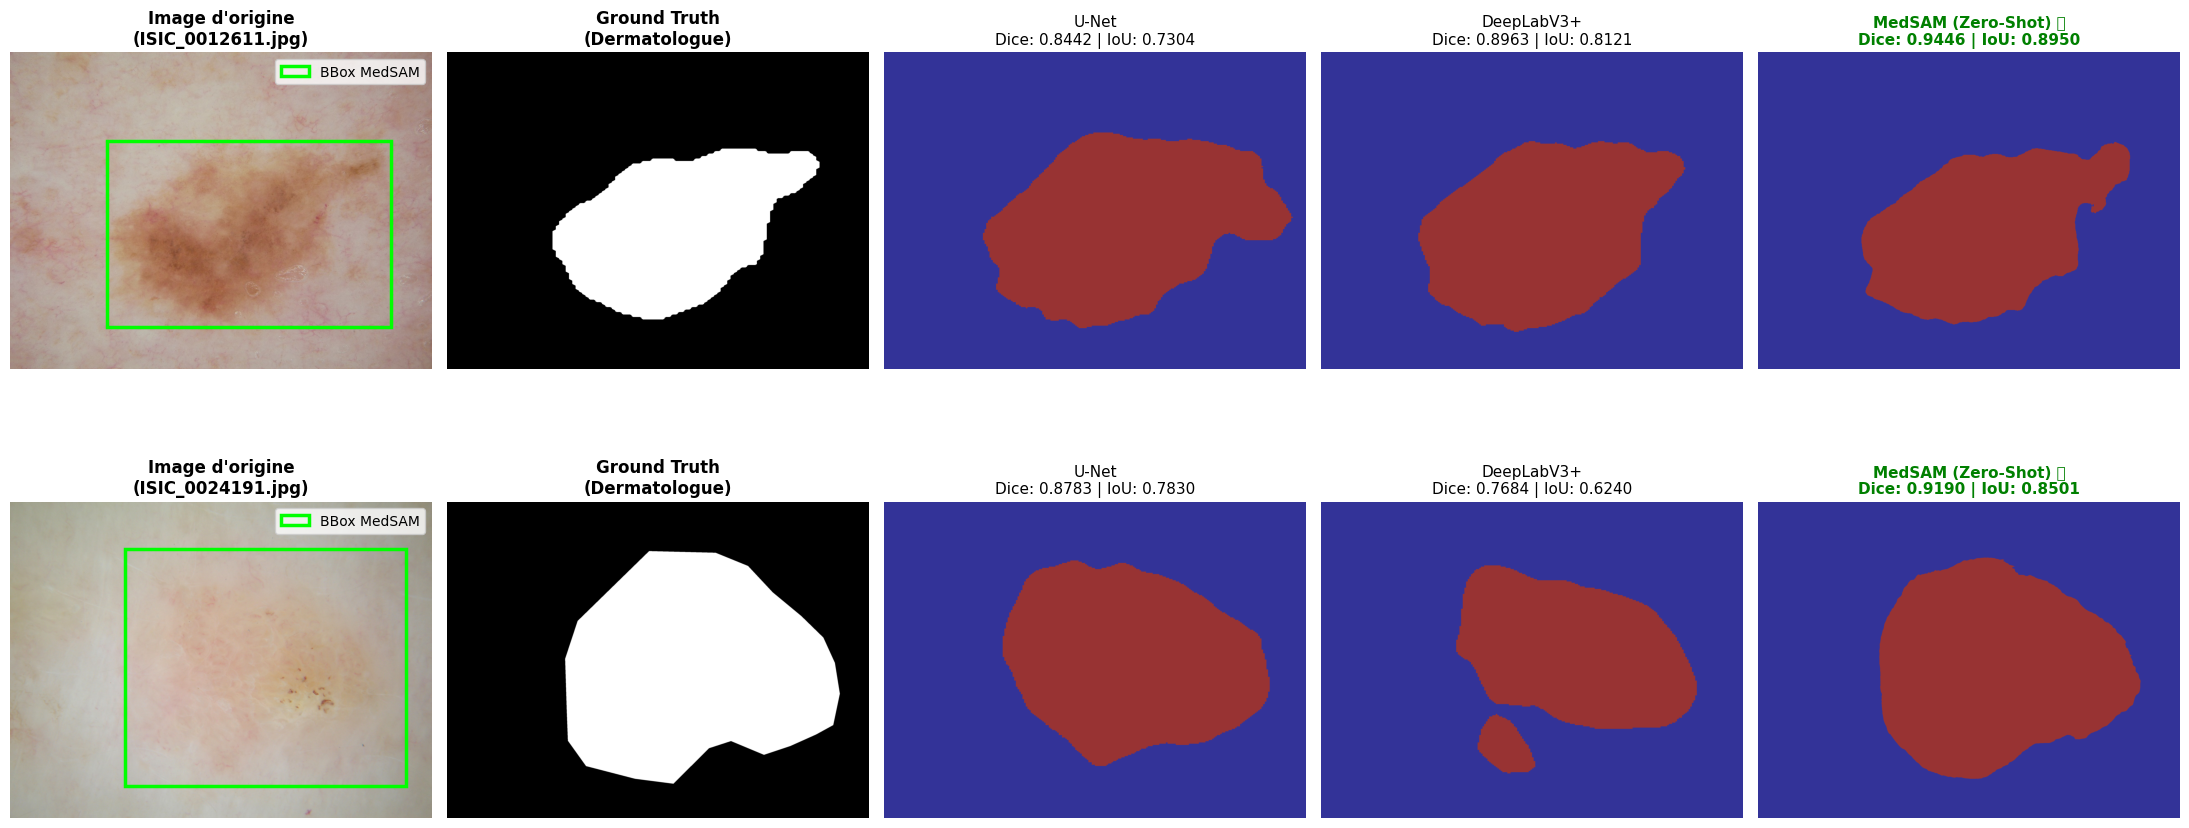


             RÉSUMÉ DU BENCHMARK COMPARATIF DES MODELES


,Image,U-Net Dice,U-Net IoU,DeepLabV3+ Dice,DeepLabV3+ IoU,MedSAM Dice,MedSAM IoU
0,ISIC_0023201.jpg,0.9407,0.8880,0.9460,0.8975,0.9144,0.8423
1,ISIC_0015596.jpg,0.8425,0.7279,0.8611,0.7561,0.8588,0.7525
2,ISIC_0012611.jpg,0.8442,0.7304,0.8963,0.8121,0.9446,0.8950
3,ISIC_0024191.jpg,0.8783,0.7830,0.7684,0.6240,0.9190,0.8501


In [10]:
# Tableau pour collecter les scores quantitatifs
results_df = []
saved_plots_data = []

# 1. Exécuter l'inférence et afficher CHAQUE test individuellement
for idx in selected_indices:
    img_path = test_images_paths[idx]
    mask_path = test_masks_paths[idx]
    filename = os.path.basename(img_path)
    
    # Lecture de l'image d'origine
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    H, W, C = img_rgb.shape
    
    # Lecture du masque de vérité terrain
    mask_gt = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask_gt_binary = (mask_gt > 127).astype(np.uint8)
    
    # ==========================================
    # INFÉRENCE U-NET & DEEPLABV3+ (Resolution: 256x256)
    # ==========================================
    img_resized = cv2.resize(img_rgb, (256, 256))
    img_normalized = img_resized / 255.0
    img_input = np.expand_dims(img_normalized, axis=0)
    
    # Prediction U-Net
    pred_unet = unet_model.predict(img_input)[0]
    pred_unet_mask_256 = (pred_unet > 0.5).astype(np.uint8)
    pred_unet_mask = cv2.resize(pred_unet_mask_256, (W, H), interpolation=cv2.INTER_NEAREST)
    
    # Prediction DeepLabV3+
    pred_deeplab = deeplab_model.predict(img_input)[0]
    pred_deeplab_mask_256 = (pred_deeplab > 0.5).astype(np.uint8)
    pred_deeplab_mask = cv2.resize(pred_deeplab_mask_256, (W, H), interpolation=cv2.INTER_NEAREST)
    
    # ==========================================
    # INFÉRENCE MedSAM (Resolution: Originale + Bounding Box)
    # ==========================================
    bbox = get_bounding_box(mask_gt_binary, margin=20)
    
    # Prediction MedSAM
    predictor.set_image(img_rgb)
    input_box = np.array(bbox)
    
    masks_medsam, _, _ = predictor.predict(
        point_coords=None,
        point_labels=None,
        box=input_box[None, :],
        multimask_output=False,
    )
    pred_medsam_mask = masks_medsam[0].astype(np.uint8)
    
    # ==========================================
    # CALCUL DES SCORES DE PERFORMANCE (DICE & IOU)
    # ==========================================
    # U-Net
    dice_unet = compute_dice_numpy(mask_gt_binary, pred_unet_mask)
    iou_unet = compute_iou_numpy(mask_gt_binary, pred_unet_mask)
    
    # DeepLabV3+
    dice_deeplab = compute_dice_numpy(mask_gt_binary, pred_deeplab_mask)
    iou_deeplab = compute_iou_numpy(mask_gt_binary, pred_deeplab_mask)
    
    # MedSAM
    dice_medsam = compute_dice_numpy(mask_gt_binary, pred_medsam_mask)
    iou_medsam = compute_iou_numpy(mask_gt_binary, pred_medsam_mask)
    
    results_df.append({
        'Image': filename,
        'U-Net Dice': dice_unet, 'U-Net IoU': iou_unet,
        'DeepLabV3+ Dice': dice_deeplab, 'DeepLabV3+ IoU': iou_deeplab,
        'MedSAM Dice': dice_medsam, 'MedSAM IoU': iou_medsam
    })
    
    # Enregistrer les données pour le tracé groupé final
    saved_plots_data.append({
        'filename': filename,
        'img_rgb': img_rgb,
        'mask_gt_binary': mask_gt_binary,
        'bbox': bbox,
        'pred_unet_mask': pred_unet_mask,
        'dice_unet': dice_unet, 'iou_unet': iou_unet,
        'pred_deeplab_mask': pred_deeplab_mask,
        'dice_deeplab': dice_deeplab, 'iou_deeplab': iou_deeplab,
        'pred_medsam_mask': pred_medsam_mask,
        'dice_medsam': dice_medsam, 'iou_medsam': iou_medsam
    })
    
    # --- AFFICHAGE DE CE TEST INDIVIDUEL ---
    fig, axes = plt.subplots(1, 5, figsize=(22, 5))
    
    # 1. Image originale avec Bounding Box
    axes[0].imshow(img_rgb)
    x_min, y_min, x_max, y_max = bbox
    rect = plt.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                         edgecolor='lime', facecolor='none', linewidth=2.5, label='BBox MedSAM')
    axes[0].add_patch(rect)
    axes[0].set_title(f"Image d'origine\n({filename})", fontsize=12, fontweight='bold')
    axes[0].axis('off')
    axes[0].legend(loc='upper right')

    # 2. Vérité terrain
    axes[1].imshow(mask_gt_binary, cmap='gray')
    axes[1].set_title("Ground Truth\n(Dermatologue)", fontsize=12, fontweight='bold')
    axes[1].axis('off')

    # 3. Prédiction U-Net
    axes[2].imshow(pred_unet_mask, cmap='jet', alpha=0.8)
    axes[2].set_title(f"U-Net\nDice: {dice_unet:.4f} | IoU: {iou_unet:.4f}", fontsize=11)
    axes[2].axis('off')

    # 4. Prédiction DeepLabV3+
    axes[3].imshow(pred_deeplab_mask, cmap='jet', alpha=0.8)
    axes[3].set_title(f"DeepLabV3+\nDice: {dice_deeplab:.4f} | IoU: {iou_deeplab:.4f}", fontsize=11)
    axes[3].axis('off')

    # 5. Prédiction MedSAM
    axes[4].imshow(pred_medsam_mask, cmap='jet', alpha=0.8)
    medsam_won = dice_medsam > dice_unet and dice_medsam > dice_deeplab
    title_suffix = " 🏆" if medsam_won else ""
    title_color = "green" if medsam_won else "black"
    axes[4].set_title(f"MedSAM (Zero-Shot){title_suffix}\nDice: {dice_medsam:.4f} | IoU: {iou_medsam:.4f}",
                      fontsize=11, fontweight='bold' if medsam_won else 'normal', color=title_color)
    axes[4].axis('off')

    plt.tight_layout()
    plt.show()

# 2. RE-AFFICHAGE CONCATÉNÉ UNIQUEMENT DES TESTS GAGNANTS (MedSAM)
medsam_advantages = [
    data for data in saved_plots_data
    if data['dice_medsam'] > data['dice_unet'] and data['dice_medsam'] > data['dice_deeplab']
]

print("\n" + "="*80)
print("             TESTS CONCATÉNÉS OÙ MedSAM A GAGNÉ (🏆)")
print("="*80)

if len(medsam_advantages) == 0:
    print("ℹ️ MedSAM n'a pas strictement surpassé les deux baselines sur ces images d'exemples.")
else:
    num_plots = len(medsam_advantages)
    fig, axes = plt.subplots(num_plots, 5, figsize=(22, 5 * num_plots))
    
    # Si num_plots == 1, axes est 1D, on le convertit en 2D pour homogénéité
    if num_plots == 1:
        axes = np.expand_dims(axes, axis=0)
        
    for idx, data in enumerate(medsam_advantages):
        # 1. Image originale avec Bounding Box
        axes[idx, 0].imshow(data['img_rgb'])
        x_min, y_min, x_max, y_max = data['bbox']
        rect = plt.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                             edgecolor='lime', facecolor='none', linewidth=2.5, label='BBox MedSAM')
        axes[idx, 0].add_patch(rect)
        axes[idx, 0].set_title(f"Image d'origine\n({data['filename']})", fontsize=12, fontweight='bold')
        axes[idx, 0].axis('off')
        axes[idx, 0].legend(loc='upper right')

        # 2. Vérité terrain
        axes[idx, 1].imshow(data['mask_gt_binary'], cmap='gray')
        axes[idx, 1].set_title("Ground Truth\n(Dermatologue)", fontsize=12, fontweight='bold')
        axes[idx, 1].axis('off')

        # 3. Prédiction U-Net
        axes[idx, 2].imshow(data['pred_unet_mask'], cmap='jet', alpha=0.8)
        axes[idx, 2].set_title(f"U-Net\nDice: {data['dice_unet']:.4f} | IoU: {data['iou_unet']:.4f}", fontsize=11)
        axes[idx, 2].axis('off')

        # 4. Prédiction DeepLabV3+
        axes[idx, 3].imshow(data['pred_deeplab_mask'], cmap='jet', alpha=0.8)
        axes[idx, 3].set_title(f"DeepLabV3+\nDice: {data['dice_deeplab']:.4f} | IoU: {data['iou_deeplab']:.4f}", fontsize=11)
        axes[idx, 3].axis('off')

        # 5. Prédiction MedSAM (Gagnant)
        axes[idx, 4].imshow(data['pred_medsam_mask'], cmap='jet', alpha=0.8)
        axes[idx, 4].set_title(f"MedSAM (Zero-Shot) 🏆\nDice: {data['dice_medsam']:.4f} | IoU: {data['iou_medsam']:.4f}",
                               fontsize=11, fontweight='bold', color='green')
        axes[idx, 4].axis('off')

    plt.tight_layout()
    plt.show()

# ==========================================
# TABLEAU COMPARATIF FINAL
# ==========================================
df_summary = pd.DataFrame(results_df)
print("\n" + "="*80)
print("             RÉSUMÉ DU BENCHMARK COMPARATIF DES MODELES")
print("="*80)
display(df_summary.style.format({
    'U-Net Dice': '{:.4f}', 'U-Net IoU': '{:.4f}',
    'DeepLabV3+ Dice': '{:.4f}', 'DeepLabV3+ IoU': '{:.4f}',
    'MedSAM Dice': '{:.4f}', 'MedSAM IoU': '{:.4f}'
}).background_gradient(cmap='Greens', subset=['U-Net Dice', 'DeepLabV3+ Dice', 'MedSAM Dice']))
